In [4]:
import matplotlib.pyplot as plt
from algorithms.tss_file import TSSFile
import os

def find_file(filename, search_dir):
    for root, dirs, files in os.walk(search_dir):
        if filename in files:
            return root
    return None

In [ ]:
folder = r'Z:\DynamicTestData\T12010\dvdt NLPPD Test'
frame_to_plot = 50     # To define which frame to plot
channel_number = 4     # To define how many channel numbers to plot
tss_files = [
    #'2601A000LR_400V_5kHz_MC_Gate0V_30K_Pulses_100Frames_0.571mA_Rg_on4.7R.tss',
    #'2601A000LR_400V_5kHz_MC_Gate0V_30K_Pulses_100Frames_0.678mA.tss',
    #'2601A000LR_400V_5kHz_MC_Gate1V_30K_Pulses_100Frames_0.545mA.tss',
    #'2601A000LR_400V_5kHz_MC_Gate2V_30K_Pulses_100Frames_0.525mA.tss',
    #'2601A000LR_400V_5kHz_MC_Gate3V_30K_Pulses_100Frames_0.481mA.tss',
    #'2601A000LR_400V_5kHz_MC_Gate4V_30K_Pulses_100Frames_0.400mA.tss',
    #'2601A000LR_400V_5kHz_MC_Gate6V_30K_Pulses_100Frames_0.380mA.tss',
    '2601A000LR_400V_5kHz_RgONHS4_4.7R_MC_Gate3V_30K_Pulses_100Frames_0.488mA.tss'
]

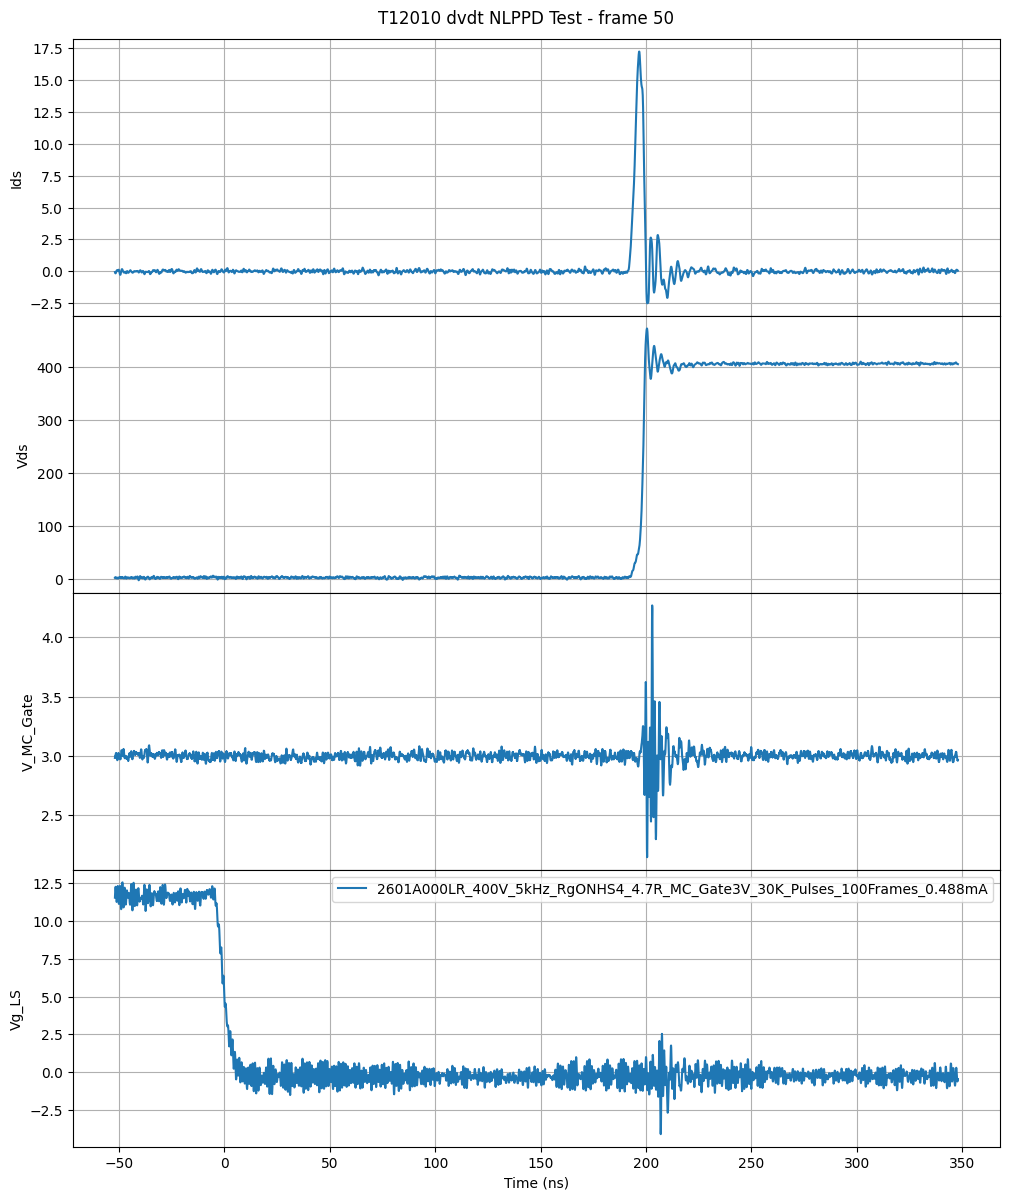

In [6]:
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 12))
fig.suptitle(f'T12010 dvdt NLPPD Test - frame {frame_to_plot}')
fig.tight_layout()
fig.subplots_adjust(hspace=0)

for tss_file in tss_files:
    path = find_file(tss_file, folder)
    tss = TSSFile(path, tss_file, source='Local')
    channel_labels = tss.channel_labels
    # num = len(channel_labels.keys())
    time = tss.waveforms[list(channel_labels.keys())[0]].time_for_frame()*1e9   # Make time unit to ns

    index = 0
    #for channel in channel_labels.keys():
    for channel in ['ch2', 'ch3', 'ch4', 'ch1']:     # Re-order the channel sequence showing in the plot
        values = tss.waveforms[channel].values_for_frame(frame_to_plot)
        axs[index].plot(time, values, label=tss_file[:-4])
        axs[index].set_ylabel(channel_labels[channel])
        axs[index].grid(True)
        index += 1

plt.legend()
plt.xlabel('Time (ns)')
#plt.xlim([-2, 2])
#plt.legend(loc='best')
plt.show()
    